# Breast Cancer Classification using Machine Learning
Data: [sklearn breast cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

## Import Packages

In [1]:
# check python version
import sys
import scipy
import numpy
import matplotlib
import seaborn
import pandas
import sklearn

# if any errors, must install the packages
print('Python: {}'.format(sys.version))
print('scipy: {}'.format(scipy.__version__))
print('numpy: {}'.format(numpy.__version__))
print('matplotlib: {}'.format(matplotlib.__version__))
print('seaborn: {}'.format(seaborn.__version__))
print('pandas: {}'.format(pandas.__version__))
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]
scipy: 1.13.1
numpy: 1.26.4
matplotlib: 3.10.0
seaborn: 0.13.2
pandas: 2.2.3
sklearn: 1.6.1


In [2]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



## Import and Explore Data

In [3]:
cancer = datasets.load_breast_cancer()

In [4]:
print('dataset shape:\n', cancer.data.shape)
print('cancer dataset targets:\n', cancer.target_names)
print('cancer dataset features:\n', cancer.feature_names)
#print(cancer.DESCR)

dataset shape:
 (569, 30)
cancer dataset targets:
 ['malignant' 'benign']
cancer dataset features:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [5]:
df = datasets.load_breast_cancer(as_frame=True).frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


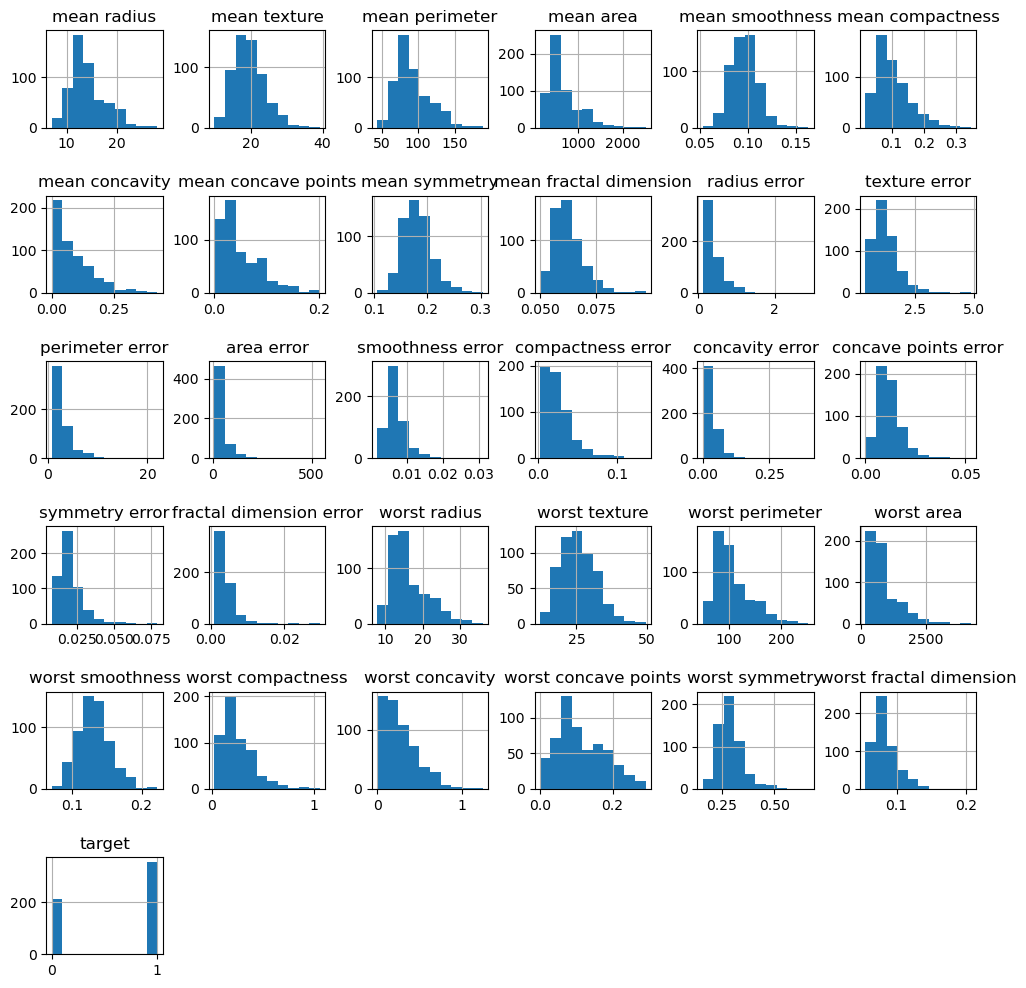

In [6]:
df.hist(figsize=(12,12))
plt.subplots_adjust(hspace=0.7, wspace=0.4);

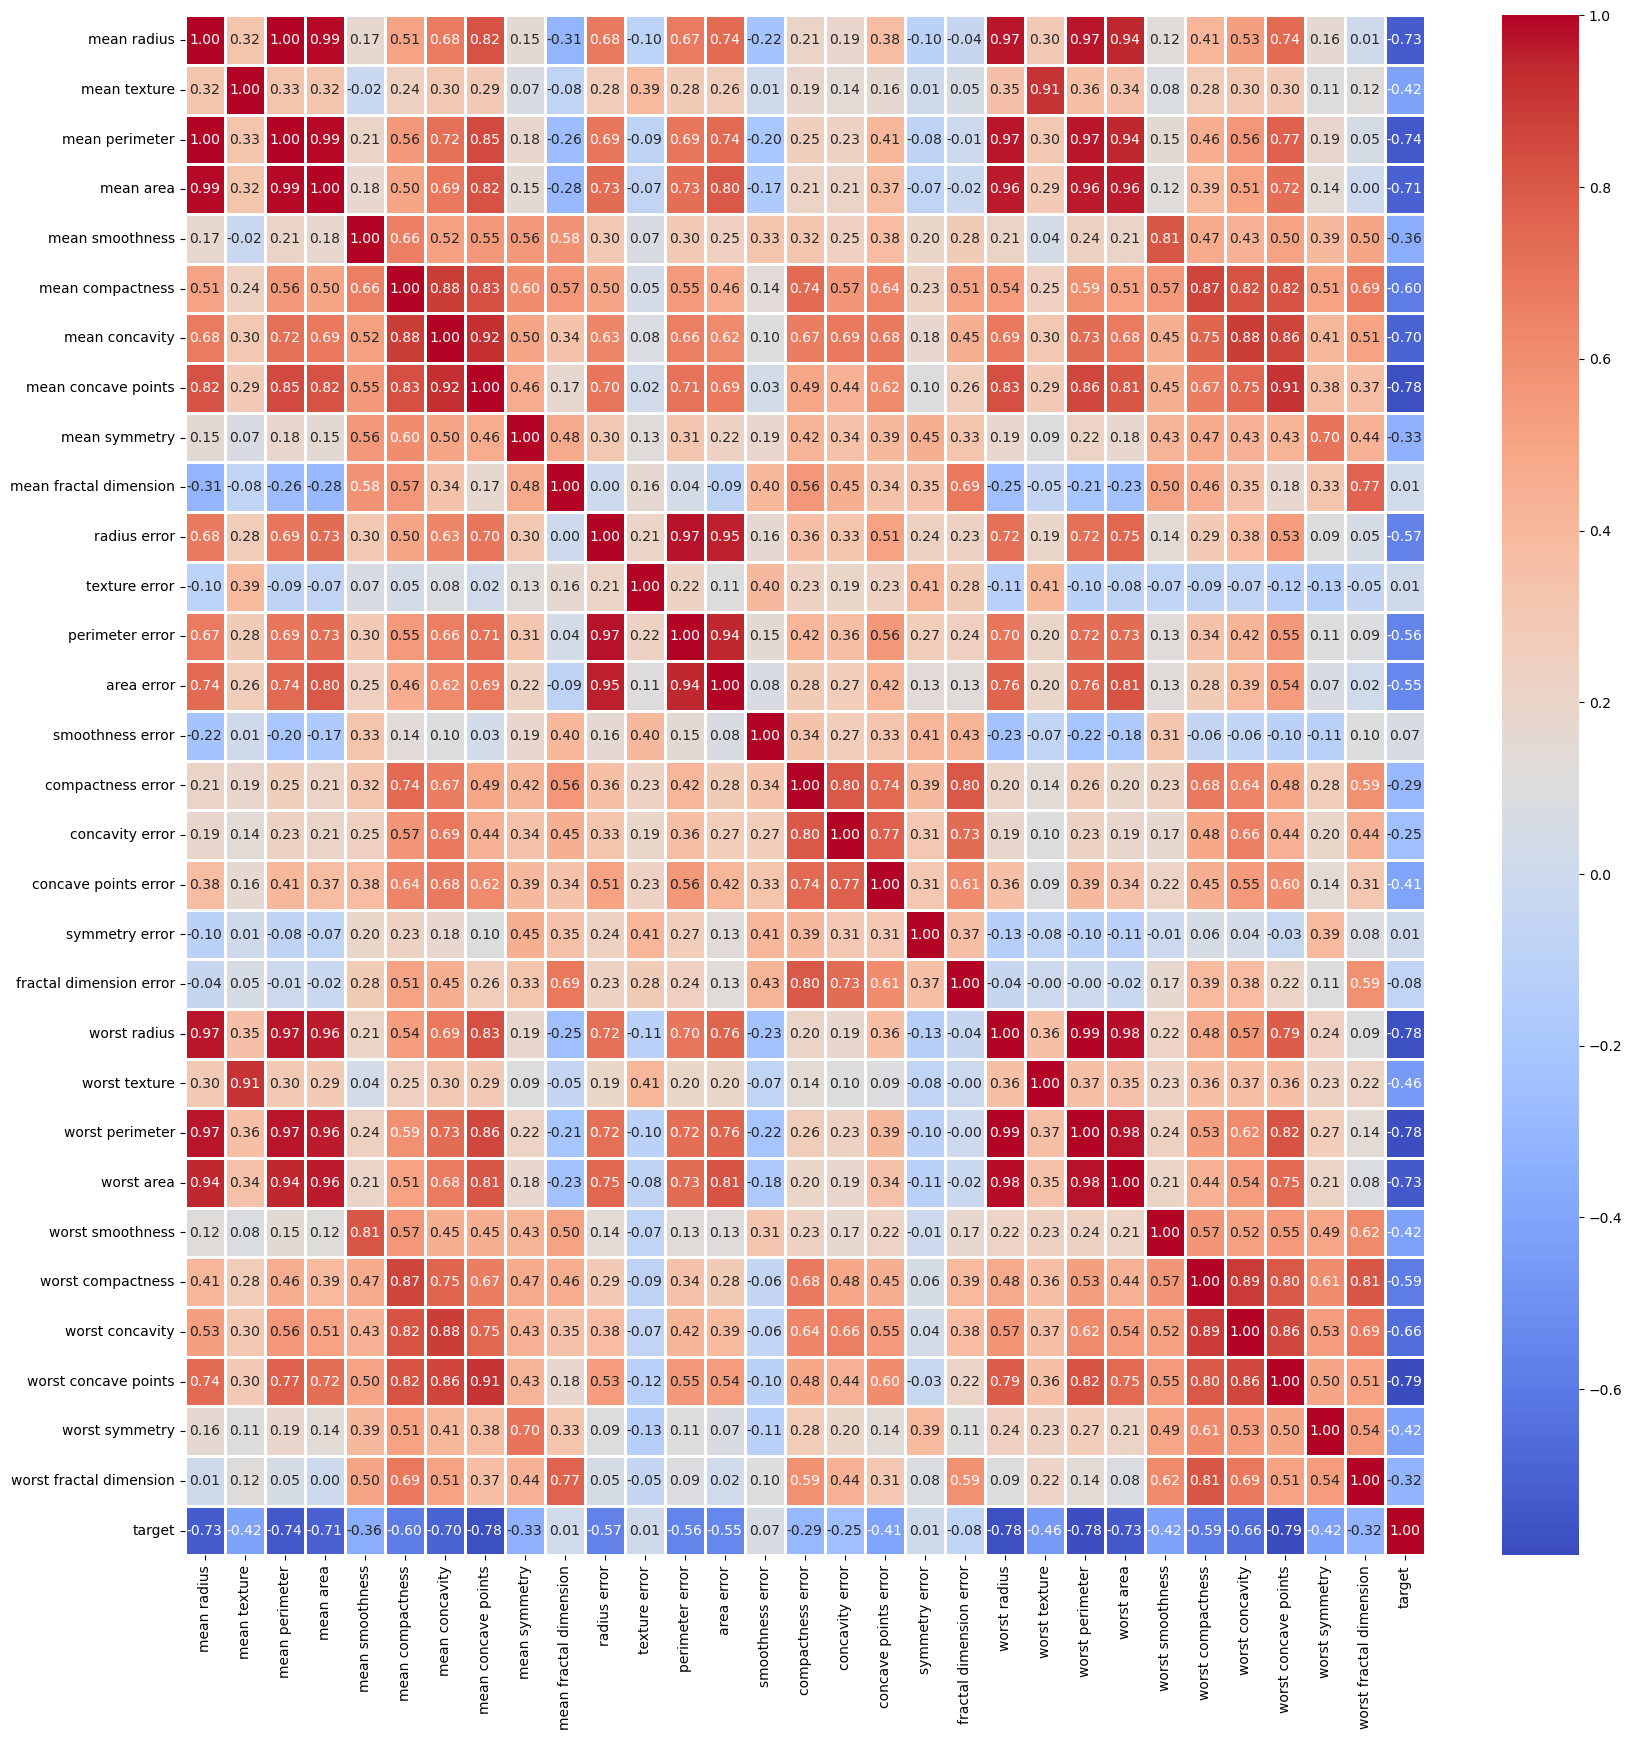

In [7]:
# correlation heatmap
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1);

The matrix shows some strong positive correlations. It would be worth exploring if these features can determine a classification with high accuracy. However, because of the complexity of cancer cells and possible non-linear patterns, we will use a random forest classification. Although the dataset does not contain a large number of rows, a random forest genralizes well.

## Model Training

In [8]:
seed = 123

# assign feature and target variables
X = cancer.data
y = cancer.target

# splitting the test set 
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.25
                                                          ,stratify=y, random_state=seed) 

In [9]:
# function to get evaluation metrics
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tp, fp, fn, tn = confusion_matrix(y_true, y_pred).ravel() # ravel flattens the matrix
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    return accuracy, precision, recall, f1, sensitivity, specificity

In [10]:
# TODO: pipeline?, explore other models (SVC, KNN)

# k-fold cross validation values
k_values = [3, 5, 7, 10, 15]

# hyperparameter grid
param_grid = {
    'n_estimators': [10, 50, 100], # number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # number of features to consider at every split
    'max_depth': [10, 20, 30], # maximum number of levels in each decision tree
    'min_samples_split': [2, 5, 10], # minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # minimum number of samples required at each leaf node
    'bootstrap': [True, False] # resampling
}

results = {}

for k in k_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

    fold_results = []
    
    for train_i, val_i in skf.split(X_trainval, y_trainval):
        # split the data
        X_train, X_val = X_trainval[train_i], X_trainval[val_i]
        y_train, y_val = y_trainval[train_i], y_trainval[val_i]
        
        rfc = RandomForestClassifier(random_state=seed)
        
        # random search for hyperparameter tuning
        grid_random_search = RandomizedSearchCV(
            estimator=rfc
            ,param_distributions=param_grid
            ,cv=5
            ,return_train_score=True
            ,random_state=seed
            ,scoring='f1'
            )
        
        # fit model and find the best
        grid_random_search.fit(X_train, y_train)

        best_model = grid_random_search.best_estimator_

        # evaluate best model
        y_pred = best_model.predict(X_val)

        # evaluation metrics
        accuracy, precision, recall, f1, sensitivity, specificity = evaluate_model(y_val, y_pred)

        fold_results.append((accuracy, precision, recall, f1, sensitivity, specificity, grid_random_search.best_params_))

    results[k] = fold_results

In [11]:
# best model for each k
for k, scores in results.items():
    accuracy, precision, recall, f1, sensitivity, specificity, best_params = scores[0]
    print(f'\nk={k}\tAccuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}\n\tBest Parameters: {best_params}')



k=3	Accuracy: 0.9577, Precision: 0.9462, Recall: 0.9888, F1-Score: 0.9670, Sensitivity: 0.9796, Specificity: 0.9462
	Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

k=5	Accuracy: 0.9535, Precision: 0.9310, Recall: 1.0000, F1-Score: 0.9643, Sensitivity: 1.0000, Specificity: 0.9310
	Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}

k=7	Accuracy: 0.9180, Precision: 0.9048, Recall: 0.9744, F1-Score: 0.9383, Sensitivity: 0.9474, Specificity: 0.9048
	Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

k=10	Accuracy: 0.9535, Precision: 0.9310, Recall: 1.0000, F1-Score: 0.9643, Sensitivity: 1.0000, Specificity: 0.9310
	Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max

- **Accuracy** measures the proportion of correct classifications (TP + TN) to all classifications (n).
  - *Assessment:*
  The model performs well in predicting both malignant and benign cases with a consistently high accuracy, ranging from 0.9180 to 0.9577. The accuracy drops slightly for k 7 and 15, which could indicate some overfitting with higher numbers of splits.

- **Precision** measures the proportion of correct positive classifications (TP) to all positive classifications (TP + FP) (avoiding false positives).
  - *Assessment:*
  The model minimizes false positives well with a reasonably high precision between 0.9000 and 0.9462. The accuracy drops slightly for k 7 and 15 (predicting more benign cases as malignant), which could again indicate some overfitting.

- **Recall** measures the proportion of correct positive classifications (TP) to all actual positives (TP + FN) (avoiding false negatives).
  - *Assessment:*
  A high recall is desirable in this case, because the consequences of false negatives is high. The model is performing very well across all k (0.9744 to 1.000), with a slight dip at k 7.

- **F1-Score** is the harmonic mean of precision and recall (2\*precision\*recall / precision+recall). It measures how effectively the model balances false positives (precision) and false negatives (recall). 
  - *Assessment:*
  The model maintains a good balance between precision and recall at all k, ranging from 0.9383 to 0.9670. Due to the lower performance of k 7 and 15 in precision, the f1-score is also lower.

**Conclusion**: k 3 and 5 perform best overall with quite different best parameters. We will choose the model with the highest f1-score for the testing.

## Testing and Evaluation

In [12]:
# get parameters of k with highest f1 score
k_best_f1 = max(results, key=lambda k: results[k][0][3])
params_best_f1 = results[k_best_f1][0][6]

print(f'Best params for k={k_best_f1} with highest F1-Score: {params_best_f1}')

Best params for k=3 with highest F1-Score: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


In [13]:
# evaluate the best model
rfc = RandomForestClassifier(random_state=seed, **params_best_f1) # can input the best parameters

rfc.fit(X_trainval, y_trainval)

y_test_pred = rfc.predict(X_test)

accuracy, precision, recall, f1, sensitivity, specificity = evaluate_model(y_test, y_test_pred)

print(f'Test Set Evaluation (k={k_best_f1} best params):\nAccuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}')


Test Set Evaluation (k=3 best params):
Accuracy: 0.9720, Precision: 0.9674, Recall: 0.9889, F1-Score: 0.9780, Sensitivity: 0.9804, Specificity: 0.9674


The evaluation metrics of the test set are a bit higher than during training. The lower error indicates some underfitting and low variance. Next steps would be to further tune the hyperparameters, perform feature engineering, and compare the results to other models like an SVC or KNN.